[Анализ текста с использованием данных «Симпсонов»](https://github.com/sujanjoejacob/Text-mining-with-Simpsons-Data "Ссылка на датасет")

##`1. Загрузка датасета с фразами Симпсонов`

In [5]:
import pandas as pd, google
import torch

In [6]:
filepath = "D:/Temp/Учёба/Datasets/Анализ текста с использованием данных «Симпсонов»/simpsons_script_lines.csv"

In [7]:
uploaded = google.colab.files.upload()

Saving simpsons_script_lines.csv to simpsons_script_lines.csv


In [8]:
# файл содержит некоректные строки. Исключаю их
column_names = [
    'id', 'episode_id', 'number', 'raw_text', 'timestamp_in_ms',
    'speaking_line', 'character_id', 'location_id', 'raw_character_text',
    'raw_location_text', 'spoken_words', 'normalized_text', 'word_count'
]

df = pd.read_csv(
    'simpsons_script_lines.csv',
    sep=',',
    names=column_names,
    usecols=range(13),
    engine='python',
    skiprows=1,  # Пропускаем строку с заголовками, если она некорректна
    on_bad_lines='skip')

In [9]:
print(f'Число строк: {len(df)}') #697 пропущенных строк — это всего 0,44 % от общего объёма
print(df.info())
df.head(3)

Число строк: 157619
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157619 entries, 0 to 157618
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  157619 non-null  int64  
 1   episode_id          157619 non-null  int64  
 2   number              157619 non-null  int64  
 3   raw_text            157619 non-null  object 
 4   timestamp_in_ms     157619 non-null  int64  
 5   speaking_line       157619 non-null  bool   
 6   character_id        140125 non-null  float64
 7   location_id         157216 non-null  float64
 8   raw_character_text  140125 non-null  object 
 9   raw_location_text   157216 non-null  object 
 10  spoken_words        131504 non-null  object 
 11  normalized_text     131480 non-null  object 
 12  word_count          131504 non-null  object 
dtypes: bool(1), float64(2), int64(4), object(6)
memory usage: 14.6+ MB
None


,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,9549,32,209,"Miss Hoover: No, actually, it was a little of ...",848000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...,31
1,9550,32,210,Lisa Simpson: (NEAR TEARS) Where's Mr. Bergstrom?,856000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,Where's Mr. Bergstrom?,wheres mr bergstrom,3
2,9551,32,211,Miss Hoover: I don't know. Although I'd sure l...,856000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,I don't know. Although I'd sure like to talk t...,i dont know although id sure like to talk to h...,22


##`2. Обучить word2vec на фразах персонажей`

In [10]:
!pip install gensim
!pip install compress-fasttext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for compress-fasttext: filename=compress_fasttext-0.1.5-py3-none-any.whl size=16098 sha256=5f51a6138b58d45eef225a885d9f7f88863afbceccd80e3e0d8e8ee603d9cd30
  Stored in directory: /root/.cache/pip/wheels/94/e5/fa/b6c62abc299fd232c095c58a69027826a263adad6a2a2e1aaf
Successfully built compress-fasttext


###Подготовка данных

In [11]:
import nltk
from nltk.tokenize import word_tokenize # токинезатор
from nltk.corpus import stopwords       # стоп - слова
import re
import string

nltk.download('punkt_tab')
nltk.download('stopwords')

# Стоп-слова
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Приводим к нижнему регистру
    text = text.lower() # код не обязателен для столбца "normalized_text"
    # Удаление пунктуации
    text = text.translate(str.maketrans('', '', string.punctuation)) # код не обязателен для столбца "normalized_text"
    # Токенизация
    tokens = word_tokenize(text)
    # Удаление стоп‑слова
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Применяем предобработку к колонке с репликами
sentences = df['normalized_text'].dropna().apply(preprocess_text).tolist()


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
# Пример
sentences[5:8]

[['dont', 'think', 'theres', 'anything', 'left', 'say'],
 ['bart'],
 ['victory', 'party', 'slide']]

###Обучение модели Word2Vec

In [13]:
# Параметры модели
vector_size = 100      # Размерность векторов (100–300)
window = 5             # Окно контекста (5–10)
min_count = 2          # Минимум вхождений слова (игнорируем редкие)
workers = 4            # Число потоков
sg = 0                 # CBOW (sg=1 — Skip‑gram)


print("=" * 60)
print("ПАРАМЕТРЫ МОДЕЛИ WORD2VEC")
print("=" * 60)
print(f"vector_size: 100 — размерность векторных представлений слов.")
print(f"             100 достаточно для небольшого корпуса.")
print()
print(f"window:      5 — сколько слов вокруг целевого учитывать.")
print(f"             5 — стандартное значение.")
print()
print(f"min_count:   2 — слова, встречающиеся реже, игнорируются.")
print(f"             Помогает убрать опечатки и редкие слова.")
print()
print(f"sg=0         — используем архитектуру CBOW (Continuous")
print(f"             Bag‑of‑Words): предсказываем слово по контексту.")
print("=" * 60)

ПАРАМЕТРЫ МОДЕЛИ WORD2VEC
vector_size: 100 — размерность векторных представлений слов.
             100 достаточно для небольшого корпуса.

window:      5 — сколько слов вокруг целевого учитывать.
             5 — стандартное значение.

min_count:   2 — слова, встречающиеся реже, игнорируются.
             Помогает убрать опечатки и редкие слова.

sg=0         — используем архитектуру CBOW (Continuous
             Bag‑of‑Words): предсказываем слово по контексту.


In [14]:
from gensim.models import Word2Vec

# Создаём и обучаем модель за один вызов
model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=0,
    compute_loss=True, # подсчёт потерь для мониторинга
    epochs=10
)

# Сохраняем модель
model.save("simpsons_word2vec.model")
print("Модель успешно обучена и сохранена!")

Модель успешно обучена и сохранена!


###Проверка результатов

In [15]:
# Находим слова, похожие на «homer»
similar_to_homer = model.wv.most_similar('homer', topn=5)
print("Слова, похожие на 'homer':")
for word, similarity in similar_to_homer:
    print(f"{word}: {similarity:.3f}")

# Находим «лишнее» слово в группе
odd_one = model.wv.doesnt_match(['homer', 'marge', 'bart', 'car'])
print(f"\nЛишнее слово: {odd_one}")

# Получаем вектор для слова
vector = model.wv['doughnut']
print(f"\nВектор для 'doughnut' (первые 10 элементов): {vector[:10]}")

# Проверяем, есть ли слово в словаре модели
print(f"\nСлово 'simpson' в модели: {'simpson' in model.wv}")


Слова, похожие на 'homer':
marge: 0.808
abe: 0.782
grampa: 0.679
bart: 0.652
son: 0.628

Лишнее слово: car

Вектор для 'doughnut' (первые 10 элементов): [-0.01213644  0.01913496  0.02312033 -0.0354791   0.00747589 -0.01599951
  0.00984731  0.06577659 -0.00775099 -0.01616308]

Слово 'simpson' в модели: True


##`3. Визуализировать embeddings по самым частотным словам (top 1000)`

In [16]:
# Пример вектора слова
model.wv['simpson']

array([-0.6138968 ,  1.2788492 , -0.3125002 , -2.8787928 ,  2.0928416 ,
       -0.63458276, -0.74853295,  0.12474032,  0.05587902, -1.131106  ,
        0.6261318 , -1.6177092 ,  1.0792633 ,  1.3169428 , -0.7174074 ,
       -1.0132502 , -0.24862015,  1.4287943 ,  0.01723893, -1.6093372 ,
       -0.6717947 ,  1.31602   , -0.9201855 , -1.5176073 ,  0.6539626 ,
        0.64166003,  1.3136699 , -1.1521192 , -0.8218889 , -0.41294795,
       -1.0345682 ,  0.9020981 , -1.2693976 , -2.2612083 , -0.8339981 ,
        0.22774458, -1.3978856 ,  0.56503403, -2.013593  ,  0.05634261,
        0.36703292, -0.15358624,  0.10375744, -1.3299052 , -1.3539872 ,
       -1.3375403 ,  0.04264911, -0.435732  , -1.7001184 ,  0.45886567,
        1.1818694 , -0.6914131 , -0.09003574, -1.4008923 ,  0.83739036,
       -1.864762  , -0.22987887, -1.9997063 ,  0.53746706,  0.74685663,
        1.998193  ,  0.2069949 ,  0.5856596 ,  1.4231732 , -1.6846054 ,
       -0.06435977, -0.74757457, -0.54877734, -1.0914264 ,  2.63

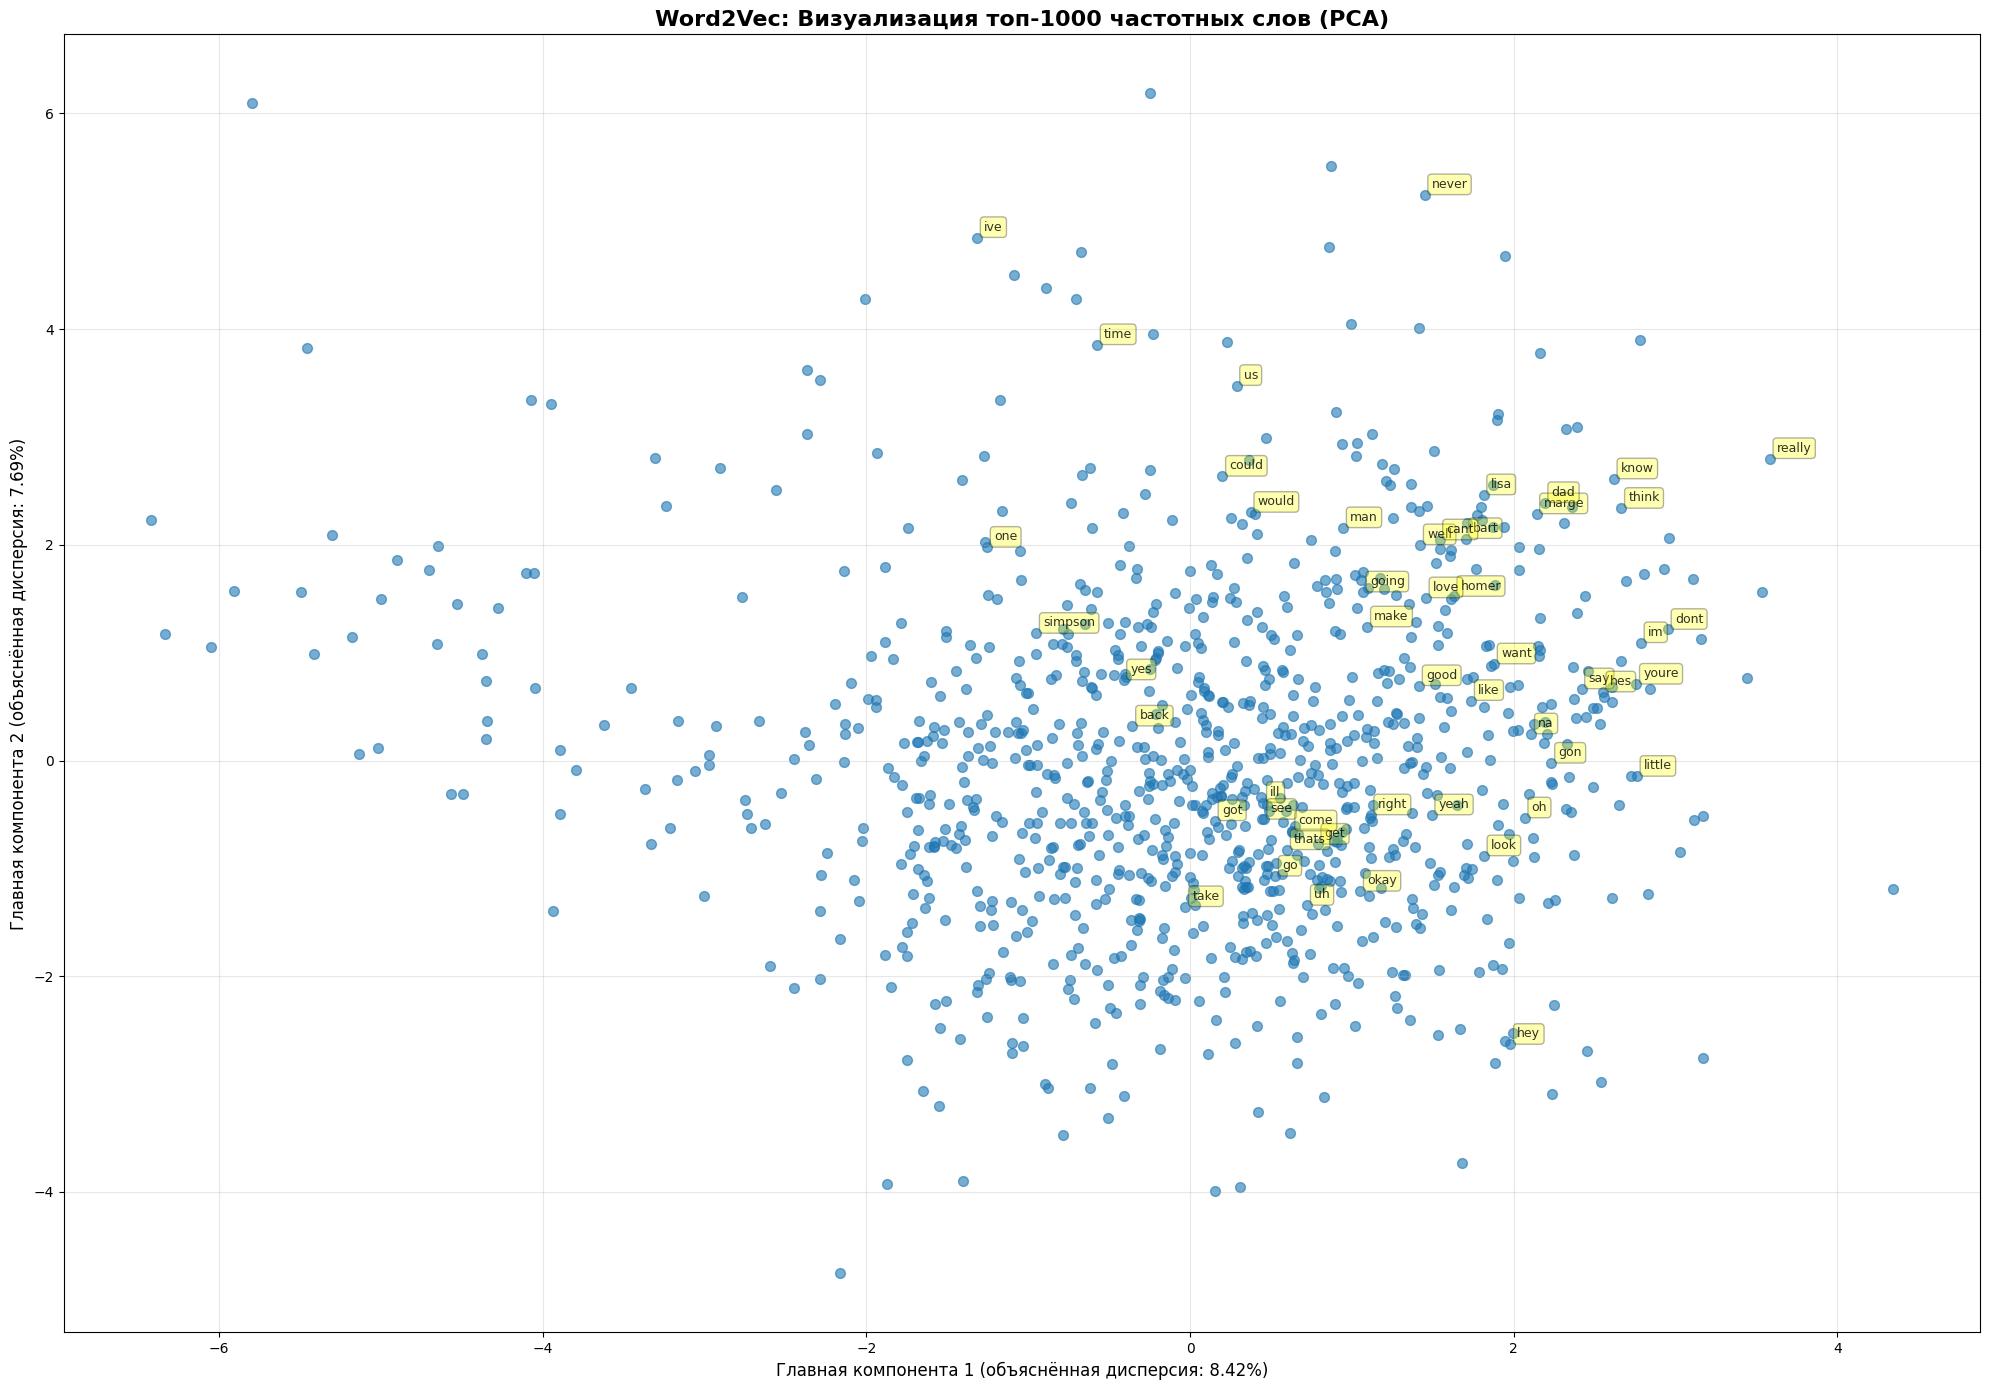

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# топ‑1000 самых частотных слов из модели
word_freq = [(word, model.wv.get_vecattr(word, 'count')) for word in model.wv.index_to_key]
# cортировка по частоте (по убыванию)
top_words_with_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:1000]
top_words = [word for word, _ in top_words_with_freq]

# Извлечение векторов для этих слов
word_vectors = [model.wv[word] for word in top_words]

# Уменьшаем размерность до 2D
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

# Построение графика
plt.figure(figsize=(20, 14))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], alpha=0.6, s=50)

# Добавляем подписи для топ‑50 самых частых слов
top_labels = top_words[:50]# взято только 50 для лучшей визуализации
label_indices = list(range(50))

for idx in label_indices:
    plt.annotate(
        top_labels[idx],
        xy=(reduced_vectors[idx, 0], reduced_vectors[idx, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        alpha=0.8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
    )

plt.title("Word2Vec: Визуализация топ‑1000 частотных слов (PCA)", fontsize=16, fontweight='bold')
plt.xlabel(f"Главная компонента 1 (объяснённая дисперсия: {pca.explained_variance_ratio_[0]:.2%})", fontsize=12)
plt.ylabel(f"Главная компонента 2 (объяснённая дисперсия: {pca.explained_variance_ratio_[1]:.2%})", fontsize=12)

# Fix внешнего вида графика
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


##`4. Найти самые близкие слова для:`

*   homer - marge + bart
*   bart - lisa + school
*   marge - homer + home

In [20]:
# Суть задачи.
"""1) Векторное представление. Каждое слово представлено вектором (vector_size - 100).

   2) Арифметика векторов. Модель выполняет сложение и вычитание векторов:

      -- вектор(homer) - вектор(marge) даёт вектор «мужских черт Симпсонов»;

      --добавление вектор(bart) смещает результат в сторону черт Барта.

   3) Поиск ближайшего. Модель ищет в словаре слово, чей вектор ближе всего к полученному результату (по косинусному сходству).

   4) Ранжирование. Слова сортируются по убыванию сходства — самые близкие выводятся первыми."""

'1) Векторное представление. Каждое слово представлено вектором (vector_size - 100).\n\n   2) Арифметика векторов. Модель выполняет сложение и вычитание векторов:\n\n      -- вектор(homer) - вектор(marge) даёт вектор «мужских черт Симпсонов»;\n\n      --добавление вектор(bart) смещает результат в сторону черт Барта.\n\n   3) Поиск ближайшего. Модель ищет в словаре слово, чей вектор ближе всего к полученному результату (по косинусному сходству).\n\n   4) Ранжирование. Слова сортируются по убыванию сходства — самые близкие выводятся первыми.'

In [22]:
# Метод most_similar находит слова, наиболее близкие по смыслу к заданному слову. Пример топ 5 на слове marge
model.wv.most_similar('marge', topn=5)

[('homer', 0.8078837394714355),
 ('honey', 0.7327997088432312),
 ('homie', 0.7116553783416748),
 ('abe', 0.7023292779922485),
 ('sweetie', 0.6830642223358154)]

In [31]:
# Функция для арифметики векторов.
def find_analogy(model, positive, negative):
    """
    Находит слово, наиболее близкое к результату векторной операции:
    positive[0] - negative[0] + positive[1]
    """
    try:
        result = model.wv.most_similar(
            positive=positive,
            negative=negative,
            topn=5  # Возвращаем 5 самых близких слов
        )

        return result
    except KeyError as e:
        return f"Ошибка: слово {e} отсутствует в модели"

In [35]:
#1) homer - marge + bart

res_1 = find_analogy(model=model, positive=['homer', 'bart'], negative='marge')

for word, similarity in res_1:
    print(f"  {word}: {similarity:.3f}")

  lisa: 0.721
  grampa: 0.623
  milhouse: 0.612
  abe: 0.611
  beelzebart: 0.603


In [36]:
#2) bart - lisa + school

res_2 = find_analogy(model=model, positive=['school', 'bart'], negative='lisa')
for word, similarity in res_2:
    print(f"  {word}: {similarity:.3f}")

  test: 0.660
  bus: 0.656
  high: 0.633
  teachers: 0.625
  psychologist: 0.624


In [37]:
#3) marge - homer + home

res_3 = find_analogy(model=model, positive=['marge', 'home'], negative='homer')
for word, similarity in res_3:
    print(f"  {word}: {similarity:.3f}")

  bed: 0.732
  along: 0.662
  sleep: 0.644
  college: 0.613
  parents: 0.602
